In [67]:
import pandas as pd

flights = pd.read_parquet("../Data/raw/flights.parquet")

flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,0005,...,0408,-22.0,0,0,None,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,0010,...,0741,-9.0,0,0,None,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,0020,...,0811,5.0,0,0,None,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,0020,...,0756,-9.0,0,0,None,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,0025,...,0259,-21.0,0,0,None,NaN,NaN,NaN,NaN,NaN


In [68]:
flights.shape

(5819079, 31)

In [69]:
for i, col in enumerate(flights.columns,start=1):
    print(i, col)

1 YEAR
2 MONTH
3 DAY
4 DAY_OF_WEEK
5 AIRLINE
6 FLIGHT_NUMBER
7 TAIL_NUMBER
8 ORIGIN_AIRPORT
9 DESTINATION_AIRPORT
10 SCHEDULED_DEPARTURE
11 DEPARTURE_TIME
12 DEPARTURE_DELAY
13 TAXI_OUT
14 WHEELS_OFF
15 SCHEDULED_TIME
16 ELAPSED_TIME
17 AIR_TIME
18 DISTANCE
19 WHEELS_ON
20 TAXI_IN
21 SCHEDULED_ARRIVAL
22 ARRIVAL_TIME
23 ARRIVAL_DELAY
24 DIVERTED
25 CANCELLED
26 CANCELLATION_REASON
27 AIR_SYSTEM_DELAY
28 SECURITY_DELAY
29 AIRLINE_DELAY
30 LATE_AIRCRAFT_DELAY
31 WEATHER_DELAY


In [70]:
flights.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE     object
DEPARTURE_TIME          object
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF              object
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON               object
TAXI_IN                float64
SCHEDULED_ARRIVAL       object
ARRIVAL_TIME            object
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [71]:
missing = flights.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

CANCELLATION_REASON    5729195
WEATHER_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
AIR_SYSTEM_DELAY       4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
ARRIVAL_TIME             92513
TAXI_IN                  92513
WHEELS_ON                92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
dtype: int64

In [72]:
flights["ARRIVAL_DELAY"].describe()

count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64

In [73]:
print("Missing arrival delays:", flights["ARRIVAL_DELAY"].isna().sum())

Missing arrival delays: 105071


In [74]:
print("Cancelled flights:", flights["CANCELLED"].sum())
print("Cancelled percentage:", flights["CANCELLED"].mean() * 100)

Cancelled flights: 89884
Cancelled percentage: 1.5446430612129514


In [75]:
print("Diverted flights:", flights["DIVERTED"].sum())
print("Diverted percentage:", flights["DIVERTED"].mean() * 100)

Diverted flights: 15187
Diverted percentage: 0.26098631759424473


In [76]:
print(
    flights.loc[flights["ARRIVAL_DELAY"].isna(), ["CANCELLED", "DIVERTED"]]
    .value_counts()
)

CANCELLED  DIVERTED
1          0           89884
0          1           15187
Name: count, dtype: int64


<Axes: title={'center': 'Distribution of Flight Arrival Delays'}, ylabel='Frequency'>

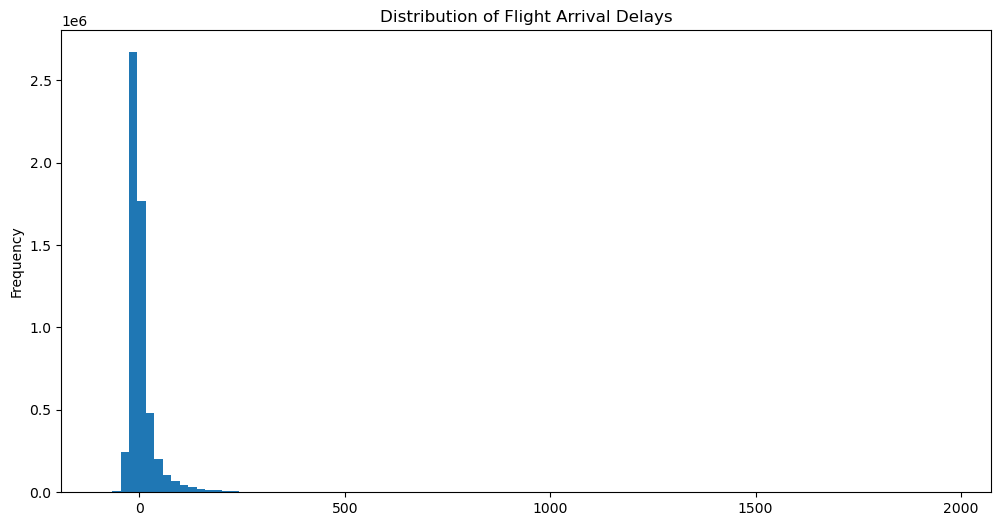

In [77]:
flights["ARRIVAL_DELAY"].plot(
    kind="hist",
    bins=100,
    figsize=(12, 6),
    title="Distribution of Flight Arrival Delays"
)

In [78]:
print("On-time / early:", (flights["ARRIVAL_DELAY"] < 15).sum())
print("Delayed 15+ min:", (flights["ARRIVAL_DELAY"] >= 15).sum())

On-time / early: 4650569
Delayed 15+ min: 1063439


In [79]:
missing_arrival = flights["ARRIVAL_DELAY"].isna()

print("Missing ARRIVAL_DELAY:", missing_arrival.sum())
print(
    "Cancelled or diverted among missing:",
    flights.loc[missing_arrival, ["CANCELLED", "DIVERTED"]].sum().sum()
)

Missing ARRIVAL_DELAY: 105071
Cancelled or diverted among missing: 105071


In [80]:
on_time = (flights["ARRIVAL_DELAY"] < 15).sum()
delayed = (flights["ARRIVAL_DELAY"] >= 15).sum()

print("On-time / early:", on_time)
print("Delayed 15+ min:", delayed)

On-time / early: 4650569
Delayed 15+ min: 1063439


In [81]:
total_completed = on_time + delayed

delay_rate = delayed / total_completed * 100

print("Eligible flights:", total_completed)
print("Delay rate:", delay_rate)

Eligible flights: 5714008
Delay rate: 18.611086998828146


In [82]:
y = (flights["ARRIVAL_DELAY"] >= 15).astype(int)


print(y.value_counts())

ARRIVAL_DELAY
0    4755640
1    1063439
Name: count, dtype: int64


In [83]:
print("y = 0:", (y == 0).sum())
print("y = 1:", (y == 1).sum())
print("Missing ARRIVAL_DELAY:", flights["ARRIVAL_DELAY"].isna().sum())

y = 0: 4755640
y = 1: 1063439
Missing ARRIVAL_DELAY: 105071


In [84]:
eligible = flights["ARRIVAL_DELAY"].notna()

print("Eligible flights:", eligible.sum())
print("Excluded flights:", (~eligible).sum())

Eligible flights: 5714008
Excluded flights: 105071


In [85]:
print(y.value_counts(normalize=True) * 100)

ARRIVAL_DELAY
0    81.72496
1    18.27504
Name: proportion, dtype: float64


## Initial Target Definition

AirIntel V1 predicts whether a flight arrives at least 15 minutes late.

- Target = 1 → ARRIVAL_DELAY >= 15 minutes
- Target = 0 → ARRIVAL_DELAY < 15 minutes
- Cancelled and diverted flights are excluded from the initial prediction population because they do not have a normal arrival-delay outcome.

Initial dataset: 5,819,079 flights
Eligible flights: 5,714,008
Excluded cancelled/diverted flights: 105,071

In [86]:
print("Total y values:", len(y))
print("Eligible flights:", eligible.sum())

Total y values: 5819079
Eligible flights: 5714008


In [87]:
print(y.value_counts(normalize=True) * 100)

ARRIVAL_DELAY
0    81.72496
1    18.27504
Name: proportion, dtype: float64


In [88]:
for i, column in enumerate(flights.columns, start=1):
    print(f"{i:2}. {column}")

 1. YEAR
 2. MONTH
 3. DAY
 4. DAY_OF_WEEK
 5. AIRLINE
 6. FLIGHT_NUMBER
 7. TAIL_NUMBER
 8. ORIGIN_AIRPORT
 9. DESTINATION_AIRPORT
10. SCHEDULED_DEPARTURE
11. DEPARTURE_TIME
12. DEPARTURE_DELAY
13. TAXI_OUT
14. WHEELS_OFF
15. SCHEDULED_TIME
16. ELAPSED_TIME
17. AIR_TIME
18. DISTANCE
19. WHEELS_ON
20. TAXI_IN
21. SCHEDULED_ARRIVAL
22. ARRIVAL_TIME
23. ARRIVAL_DELAY
24. DIVERTED
25. CANCELLED
26. CANCELLATION_REASON
27. AIR_SYSTEM_DELAY
28. SECURITY_DELAY
29. AIRLINE_DELAY
30. LATE_AIRCRAFT_DELAY
31. WEATHER_DELAY


In [89]:
## Target Validation

For AirIntel V1, the prediction population consists only of flights with a recorded `ARRIVAL_DELAY`.

Target definition:

- `1` → arrival delay >= 15 minutes
- `0` → arrival delay < 15 minutes

Dataset:
- Total flights: 5,819,079
- Eligible flights: 5,714,008
- Excluded flights: 105,071
- Delayed flights: 1,063,439
- Non-delayed flights: 4,650,569

Class distribution:
- Non-delayed: 81.39%
- Delayed: 18.61%

SyntaxError: invalid character '→' (U+2192) (3031584179.py, line 7)

In [ ]:
eligible = flights["ARRIVAL_DELAY"].notna()

y = (flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)

print("Total y values:", len(y))
print(y.value_counts())

Total y values: 5714008
ARRIVAL_DELAY
0    4650569
1    1063439
Name: count, dtype: int64


In [ ]:
airlines =pd.read_parquet("../Data/raw/airlines.parquet")
airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [ ]:
airports = pd.read_parquet("../Data/raw/airports.parquet")
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [ ]:
print("Shape:", airports.shape)
print("\nColumns:")
print(airports.columns.tolist())

Shape: (322, 7)

Columns:
['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']


In [ ]:
print("Unique airline codes in flights:", flights["AIRLINE"].nunique())
print("Rows in airline lookup:", len(airlines))

print("Unique origin airports:", flights["ORIGIN_AIRPORT"].nunique())
print("Unique destination airports:", flights["DESTINATION_AIRPORT"].nunique())
print("Rows in airport lookup:", len(airports))

Unique airline codes in flights: 14
Rows in airline lookup: 14
Unique origin airports: 628
Unique destination airports: 629
Rows in airport lookup: 322


In [ ]:
airlines

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


In [ ]:
flights["ORIGIN_AIRPORT"].unique()[:50]

array(['ANC', 'LAX', 'SFO', 'SEA', 'LAS', 'DEN', 'SLC', 'PDX', 'FAI',
       'MSP', 'PHX', 'SJU', 'PBG', 'IAG', 'PSE', 'BQN', 'ORD', 'GEG',
       'HNL', 'ONT', 'MCO', 'BOS', 'HIB', 'ABR', 'MAF', 'DFW', 'MKE',
       'IAH', 'BNA', 'BRO', 'VPS', 'BOI', 'BJI', 'SGF', 'PHL', 'SBN',
       'RDD', 'EUG', 'IAD', 'BUF', 'PWM', 'JFK', 'CRP', 'PIA', 'FAT',
       'SMF', 'AUS', 'MCI', 'ATL', 'JAX'], dtype=object)

In [ ]:
print(flights["ORIGIN_AIRPORT"].dtype)
print(flights["DESTINATION_AIRPORT"].dtype)

object
object


In [ ]:
flight_origin_codes = set(flights["ORIGIN_AIRPORT"].dropna().astype(str))

airport_codes = set(airports["IATA_CODE"].dropna().astype(str))

print("Origin values in flights:", len(flight_origin_codes))
print("Airport lookup codes:", len(airport_codes))
print("Origin values NOT in lookup:", len(flight_origin_codes - airport_codes))

Origin values in flights: 628
Airport lookup codes: 322
Origin values NOT in lookup: 306


In [ ]:
unmatched_origins = sorted(flight_origin_codes - airport_codes)

print(unmatched_origins[:50])

['10135', '10136', '10140', '10141', '10146', '10154', '10155', '10157', '10158', '10165', '10170', '10185', '10208', '10257', '10268', '10279', '10299', '10333', '10372', '10397', '10408', '10423', '10431', '10434', '10469', '10529', '10551', '10561', '10577', '10581', '10599', '10620', '10627', '10631', '10685', '10693', '10713', '10721', '10728', '10731', '10732', '10739', '10747', '10754', '10779', '10781', '10785', '10792', '10800', '10821']


In [ ]:
[column for column in flights.columns if "AIRPORT" in column]

['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']

In [ ]:
[column for column in flights.columns if "ID" in column]

[]

In [ ]:
print("Origin dtype:", flights["ORIGIN_AIRPORT"].dtype)
print("Destination dtype:", flights["DESTINATION_AIRPORT"].dtype)

Origin dtype: object
Destination dtype: object


In [ ]:
flight_airlines = flights["AIRLINE"].isin(airlines["IATA_CODE"])

print("Matching airline codes:", flight_airlines.sum())
print("Unmatched airline codes:", (~flight_airlines).sum())

Matching airline codes: 5819079
Unmatched airline codes: 0


In [ ]:
print(flights["ORIGIN_AIRPORT"].head(20).tolist())

['ANC', 'LAX', 'SFO', 'LAX', 'SEA', 'SFO', 'LAS', 'LAX', 'SFO', 'LAS', 'DEN', 'LAS', 'LAX', 'SLC', 'SEA', 'ANC', 'ANC', 'SFO', 'ANC', 'PDX']


In [ ]:
origin_is_iata = flights["ORIGIN_AIRPORT"].str.len() == 3

print("3-character origin values:", origin_is_iata.sum())
print("Other origin values:", (~origin_is_iata).sum())

3-character origin values: 5332914
Other origin values: 486165


In [ ]:
print(flights.loc[~origin_is_iata, "ORIGIN_AIRPORT"].head(20).tolist())

['14747', '14771', '12889', '12892', '14771', '14771', '12892', '14869', '12892', '12892', '12892', '12892', '10299', '12889', '14747', '14771', '11292', '12889', '14107', '14747']


In [ ]:
dest_is_iata = flights["DESTINATION_AIRPORT"].str.len() == 3

print("3-character destination values:", dest_is_iata.sum())
print("Other destination values:", (~dest_is_iata).sum())

print(flights.loc[~dest_is_iata, "DESTINATION_AIRPORT"].head(20).tolist())

3-character destination values: 5332914
Other destination values: 486165
['11298', '13487', '13487', '13303', '11057', '13930', '13930', '11057', '11298', '13487', '10693', '11057', '14747', '12266', '13487', '12266', '12478', '13487', '11298', '13930']


In [ ]:
print(
    flights[
        ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
    ].head(10)
)

  ORIGIN_AIRPORT DESTINATION_AIRPORT
0            ANC                 SEA
1            LAX                 PBI
2            SFO                 CLT
3            LAX                 MIA
4            SEA                 ANC
5            SFO                 MSP
6            LAS                 MSP
7            LAX                 CLT
8            SFO                 DFW
9            LAS                 ATL


In [ ]:
print("Numeric origin IDs:",
      flights["ORIGIN_AIRPORT"].str.fullmatch(r"\d+").sum())

print("IATA origin codes:",
      flights["ORIGIN_AIRPORT"].str.fullmatch(r"[A-Z]{3}").sum())

print("Numeric destination IDs:",
      flights["DESTINATION_AIRPORT"].str.fullmatch(r"\d+").sum())

print("IATA destination codes:",
      flights["DESTINATION_AIRPORT"].str.fullmatch(r"[A-Z]{3}").sum())

Numeric origin IDs: 486165
IATA origin codes: 5332914
Numeric destination IDs: 486165
IATA destination codes: 5332914


In [ ]:
numeric_origins = (
    flights.loc[
        flights["ORIGIN_AIRPORT"].str.fullmatch(r"\d+"),
        "ORIGIN_AIRPORT"
    ]
    .value_counts()
)

numeric_origins.head(20)

ORIGIN_AIRPORT
10397    32588
13930    27652
11298    21044
11292    18136
12892    17728
14771    14170
12266    13211
14107    12921
12889    12688
13487    10584
14747    10388
10721    10164
11433     9925
11618     9622
11057     9572
13204     9047
14869     8763
12953     8590
12478     8303
10821     8022
Name: count, dtype: int64

In [ ]:
numeric_destinations = (
    flights.loc[
        flights["DESTINATION_AIRPORT"].str.fullmatch(r"\d+"),
        "DESTINATION_AIRPORT"
    ]
    .value_counts()
)

numeric_destinations.head(20)

DESTINATION_AIRPORT
10397    32594
13930    27608
11298    21033
11292    18125
12892    17739
14771    14170
12266    13227
14107    12932
12889    12702
13487    10623
14747    10385
10721    10161
11433     9913
11618     9656
11057     9573
13204     9048
14869     8764
12953     8570
12478     8285
10821     8020
Name: count, dtype: int64

In [ ]:
numeric_flights = flights[
    flights["ORIGIN_AIRPORT"].str.fullmatch(r"\d+")
]

numeric_flights[
    ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
].head(20)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4385712,14747,11298
4385713,14771,13487
4385714,12889,13487
4385715,12892,13303
4385716,14771,11057
4385717,14771,13930
4385718,12892,13930
4385719,14869,11057
4385720,12892,11298
4385721,12892,13487


In [ ]:
flights.loc[
    flights["ORIGIN_AIRPORT"] == "10397",
    ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
].head(10)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4385916,10397,10821
4385917,10397,13232
4386037,10397,12191
4386053,10397,11057
4386191,10397,11259
4386249,10397,11298
4386312,10397,12953
4386372,10397,13204
4386504,10397,13487
4386520,10397,12953


In [ ]:
flights.loc[
    flights["ORIGIN_AIRPORT"] == "10397",
    ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4385916,10397,10821
4385917,10397,13232
4386037,10397,12191
4386053,10397,11057
4386191,10397,11259


In [ ]:
print("Numeric origin IDs:", numeric_flights["ORIGIN_AIRPORT"].nunique())
print("Numeric destination IDs:",
      flights.loc[
          flights["DESTINATION_AIRPORT"].str.fullmatch(r"\d+"),
          "DESTINATION_AIRPORT"
      ].nunique())

Numeric origin IDs: 306
Numeric destination IDs: 307


In [ ]:
airline_delay_rate = (
    flights.loc[eligible]
    .assign(delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int))
    .groupby("AIRLINE")["delayed"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

airline_delay_rate

AIRLINE
NK    29.707534
F9    26.162726
B6    22.582258
MQ    21.717703
UA    20.624229
EV    19.681587
VX    19.230016
WN    19.045833
US    18.818060
OO    18.688000
AA    18.273615
DL    13.561575
AS    13.037874
HA    11.333360
Name: delayed, dtype: float64

## Initial Airline Analysis

AirIntel will evaluate airline performance using arrival-delay rate.

For this analysis:
- Cancelled and diverted flights are excluded because they have no normal arrival-delay outcome.
- A flight is considered delayed when ARRIVAL_DELAY >= 15 minutes.
- Airline delay rate = delayed eligible flights / eligible flights for that airline.

In [ ]:
airline_summary = (
    flights.loc[eligible]
    .groupby("AIRLINE")
    .agg(
        flights=("ARRIVAL_DELAY", "size"),
        delayed_flights=("ARRIVAL_DELAY", lambda x: (x >= 15).sum()),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean")
    )
)

airline_summary["delay_rate"] = (
    airline_summary["delayed_flights"]
    / airline_summary["flights"]
    * 100
)

airline_summary.sort_values("delay_rate", ascending=False)

,flights,delayed_flights,avg_arrival_delay,delay_rate
AIRLINE,,,,
NK,115193,34221,14.471800,29.707534
F9,90090,23570,12.504706,26.162726
B6,262042,59175,6.677861,22.582258
MQ,278791,60547,6.457873,21.717703
UA,507762,104722,5.431594,20.624229
EV,554752,109184,6.585379,19.681587
VX,61248,11778,4.737706,19.230016
WN,1242403,236626,4.374964,19.045833
US,194223,36549,3.706209,18.818060


In [ ]:
print("Top 5 highest delay rates:")
display(
    airline_summary.sort_values("delay_rate", ascending=False)
    [["AIRLINE", "flights", "delayed_flights", "delay_rate"]]
    .head(5)
)

print("\nBottom 5 lowest delay rates:")
display(
    airline_summary.sort_values("delay_rate", ascending=True)
    [["AIRLINE", "flights", "delayed_flights", "delay_rate"]]
    .head(5)
)

Top 5 highest delay rates:


,AIRLINE,flights,delayed_flights,delay_rate
8,NK,115193,34221,29.707534
5,F9,90090,23570,26.162726
2,B6,262042,59175,22.582258
7,MQ,278791,60547,21.717703
10,UA,507762,104722,20.624229



Bottom 5 lowest delay rates:


,AIRLINE,flights,delayed_flights,delay_rate
6,HA,76041,8618,11.333360
1,AS,171439,22352,13.037874
3,DL,870275,118023,13.561575
0,AA,712935,130279,18.273615
9,OO,576814,107795,18.688000


In [91]:
airlines = pd.read_parquet("../Data/raw/airlines.parquet")

airlines

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


In [92]:
airline_names = dict(
    zip(
        airlines["IATA_CODE"],
        airlines["AIRLINE"]
    )
)

airline_summary["AIRLINE_NAME"] = (
    airline_summary["AIRLINE"].map(airline_names)
)

In [93]:
airline_summary[
    [
        "AIRLINE",
        "AIRLINE_NAME",
        "flights",
        "delayed_flights",
        "delay_rate",
        "avg_arrival_delay"
    ]
].sort_values(
    "delay_rate",
    ascending=False
)

,AIRLINE,AIRLINE_NAME,flights,delayed_flights,delay_rate,avg_arrival_delay
8,NK,Spirit Air Lines,115193,34221,29.707534,14.471800
5,F9,Frontier Airlines Inc.,90090,23570,26.162726,12.504706
2,B6,JetBlue Airways,262042,59175,22.582258,6.677861
7,MQ,American Eagle Airlines Inc.,278791,60547,21.717703,6.457873
10,UA,United Air Lines Inc.,507762,104722,20.624229,5.431594
4,EV,Atlantic Southeast Airlines,554752,109184,19.681587,6.585379
12,VX,Virgin America,61248,11778,19.230016,4.737706
13,WN,Southwest Airlines Co.,1242403,236626,19.045833,4.374964
11,US,US Airways Inc.,194223,36549,18.818060,3.706209
9,OO,Skywest Airlines Inc.,576814,107795,18.688000,5.845652


In [94]:
airline_summary = (
    flights.loc[eligible]
    .groupby("AIRLINE")
    .agg(
        flights=("ARRIVAL_DELAY", "size"),
        delayed_flights=("ARRIVAL_DELAY", lambda x: (x >= 15).sum()),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean")
    )
    .reset_index()
)

airline_summary["delay_rate"] = (
    airline_summary["delayed_flights"]
    / airline_summary["flights"]
    * 100
)

airline_summary["AIRLINE_NAME"] = (
    airline_summary["AIRLINE"].map(airline_names)
)

airline_summary = airline_summary.sort_values(
    "delay_rate",
    ascending=False
)

airline_summary

,AIRLINE,flights,delayed_flights,avg_arrival_delay,delay_rate,AIRLINE_NAME
8,NK,115193,34221,14.471800,29.707534,Spirit Air Lines
5,F9,90090,23570,12.504706,26.162726,Frontier Airlines Inc.
2,B6,262042,59175,6.677861,22.582258,JetBlue Airways
7,MQ,278791,60547,6.457873,21.717703,American Eagle Airlines Inc.
10,UA,507762,104722,5.431594,20.624229,United Air Lines Inc.
4,EV,554752,109184,6.585379,19.681587,Atlantic Southeast Airlines
12,VX,61248,11778,4.737706,19.230016,Virgin America
13,WN,1242403,236626,4.374964,19.045833,Southwest Airlines Co.
11,US,194223,36549,3.706209,18.818060,US Airways Inc.
9,OO,576814,107795,5.845652,18.688000,Skywest Airlines Inc.


<Axes: title={'center': '2015 Airline Arrival Delay Rate'}, xlabel='Airline', ylabel='Delay Rate (%)'>

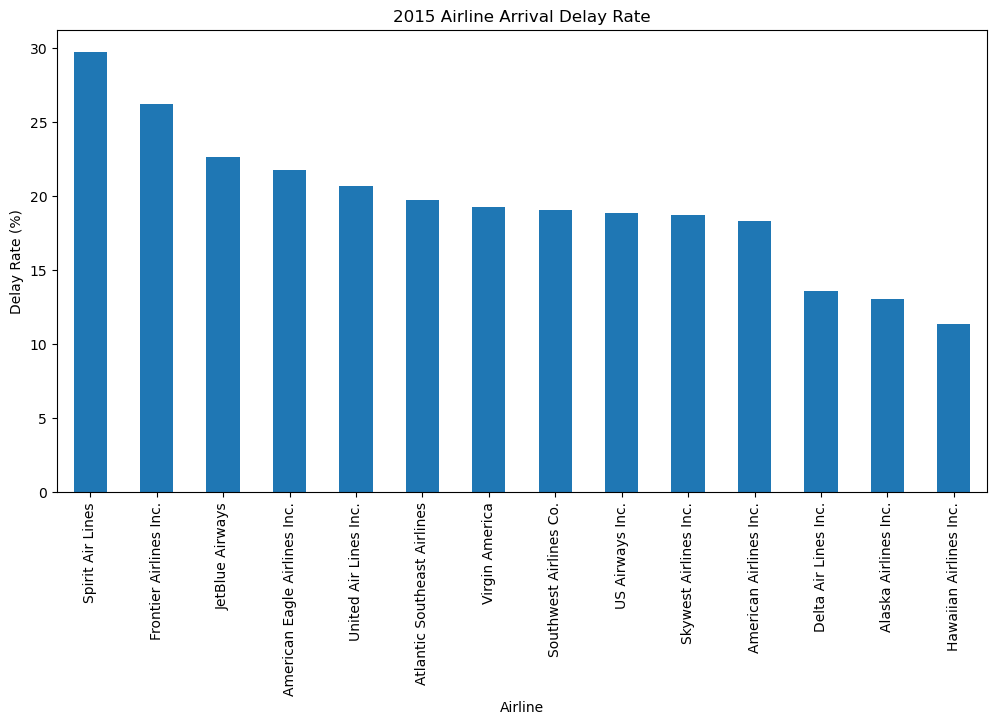

In [95]:
airline_summary.plot(
    x="AIRLINE_NAME",
    y="delay_rate",
    kind="bar",
    figsize=(12, 6),
    title="2015 Airline Arrival Delay Rate",
    ylabel="Delay Rate (%)",
    xlabel="Airline",
    legend=False
)

In [96]:
iata_origin = flights["ORIGIN_AIRPORT"].str.fullmatch(r"[A-Z]{3}")
iata_dest = flights["DESTINATION_AIRPORT"].str.fullmatch(r"[A-Z]{3}")

print("IATA origin rows:", iata_origin.sum())
print("IATA destination rows:", iata_dest.sum())

IATA origin rows: 5332914
IATA destination rows: 5332914


In [97]:
origin_counts = (
    flights.loc[iata_origin, "ORIGIN_AIRPORT"]
    .value_counts()
    .head(15)
)

origin_counts

ORIGIN_AIRPORT
ATL    346836
ORD    285884
DFW    239551
DEN    196055
LAX    194673
SFO    148008
PHX    146815
IAH    146622
LAS    133181
MSP    112117
MCO    110982
SEA    110899
DTW    108500
BOS    107847
EWR    101772
Name: count, dtype: int64

In [98]:
airport_delay_rate = (
    flights.loc[
        eligible & iata_origin,
        ["ORIGIN_AIRPORT", "ARRIVAL_DELAY"]
    ]
    .groupby("ORIGIN_AIRPORT")
    .agg(
        flights=("ARRIVAL_DELAY", "size"),
        delayed_flights=("ARRIVAL_DELAY", lambda x: (x >= 15).sum()),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean")
    )
)

airport_delay_rate["delay_rate"] = (
    airport_delay_rate["delayed_flights"]
    / airport_delay_rate["flights"]
    * 100
)

airport_delay_rate.sort_values(
    "delay_rate",
    ascending=False
).head(15)

,flights,delayed_flights,avg_arrival_delay,delay_rate
ORIGIN_AIRPORT,,,,
GST,76,34,21.763158,44.736842
ADK,88,37,11.034091,42.045455
ILG,95,37,24.063158,38.947368
PBG,278,90,9.496403,32.374101
STC,77,24,19.558442,31.168831
MMH,140,42,7.928571,30.000000
ASE,3263,968,15.492492,29.665952
PPG,106,31,21.500000,29.245283
OTH,264,72,14.333333,27.272727


In [99]:
airport_analysis = airport_delay_rate.reset_index()

airport_analysis = airport_analysis[
    airport_analysis["flights"] >= 5000
]

print("Airports with at least 5,000 eligible flights:",
      len(airport_analysis))

Airports with at least 5,000 eligible flights: 113


In [100]:
airport_analysis.sort_values(
    "delay_rate",
    ascending=False
)[
    [
        "ORIGIN_AIRPORT",
        "flights",
        "delayed_flights",
        "delay_rate",
        "avg_arrival_delay"
    ]
].head(15)

,ORIGIN_AIRPORT,flights,delayed_flights,delay_rate,avg_arrival_delay
144,HPN,7132,1764,24.733595,9.561133
228,ORD,276554,66663,24.104876,8.600790
182,LGA,94834,22709,23.946053,5.628140
203,MIA,68301,15785,23.110935,7.040805
51,BWI,84329,19049,22.588908,7.248432
319,XNA,8963,2024,22.581725,11.233850
81,DAL,58672,13176,22.457049,7.988427
85,DEN,193402,43331,22.404629,7.187909
47,BTR,6983,1557,22.297007,11.203065
116,FSD,5157,1141,22.125267,9.265077


In [101]:
airport_analysis.sort_values(
    "delay_rate",
    ascending=True
)[
    [
        "ORIGIN_AIRPORT",
        "flights",
        "delayed_flights",
        "delay_rate",
        "avg_arrival_delay"
    ]
].head(15)

,ORIGIN_AIRPORT,flights,delayed_flights,delay_rate,avg_arrival_delay
162,ITO,5708,484,8.479327,0.343203
184,LIH,10487,1018,9.707257,-1.009345
170,KOA,11052,1165,10.541079,-0.243757
141,HNL,42946,4639,10.801937,0.796465
17,ANC,15818,1988,12.567961,-0.382286
223,OGG,20477,2711,13.239244,1.071886
286,SLC,96505,13086,13.559919,0.750085
236,PDX,46777,6382,13.643457,1.204652
14,ALB,7322,1009,13.780388,-1.867249
54,CAK,5974,829,13.876799,-0.065283


In [103]:
airports = pd.read_parquet("../Data/raw/airports.parquet")

airports

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
...,...,...,...,...,...,...,...
317,WRG,Wrangell Airport,Wrangell,AK,USA,56.48433,-132.36982
318,WYS,Westerly State Airport,West Yellowstone,MT,USA,44.68840,-111.11764
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681
320,YAK,Yakutat Airport,Yakutat,AK,USA,59.50336,-139.66023


In [104]:
airport_analysis = airport_analysis.merge(
    airports[
        ["IATA_CODE", "AIRPORT", "CITY", "STATE"]
    ],
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

In [105]:
airport_analysis[
    [
        "ORIGIN_AIRPORT",
        "AIRPORT",
        "CITY",
        "STATE",
        "flights",
        "delay_rate"
    ]
].sort_values(
    "delay_rate",
    ascending=False
).head(15)

,ORIGIN_AIRPORT,AIRPORT,CITY,STATE,flights,delay_rate
43,HPN,Westchester County Airport,White Plains,NY,7132,24.733595
77,ORD,Chicago O'Hare International Airport,Chicago,IL,276554,24.104876
57,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY,94834,23.946053
67,MIA,Miami International Airport,Miami,FL,68301,23.110935
13,BWI,Baltimore-Washington International Airport,Baltimore,MD,84329,22.588908
112,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,8963,22.581725
23,DAL,Dallas Love Field,Dallas,TX,58672,22.457049
26,DEN,Denver International Airport,Denver,CO,193402,22.404629
10,BTR,Baton Rouge Metropolitan Airport,Baton Rouge,LA,6983,22.297007
35,FSD,Sioux Falls Regional Airport,Sioux Falls,SD,5157,22.125267


## Airport Analysis — Initial Finding

Airport-level delay rates vary across U.S. airports.

For the initial exploratory analysis, airports with at least 5,000 eligible flights were considered to reduce instability from very small sample sizes.

Important data-quality note:
The 2015 BTS-derived flight dataset contains both three-letter IATA airport codes and numeric DOT airport identifiers. The current airport metadata file primarily provides IATA-coded airport records. Therefore, this initial airport analysis is limited to records that can currently be identified by IATA code.

The numeric airport identifiers will be standardized through a separate crosswalk before the final AirIntel feature dataset is created.

In [106]:
scheduled_hour = (
    flights["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
    .str[:2]
    .astype(int)
)

scheduled_hour.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: SCHEDULED_DEPARTURE, dtype: int64

In [107]:
hourly_flights = scheduled_hour.value_counts().sort_index()

hourly_flights

SCHEDULED_DEPARTURE
0      14664
1       5159
2       1414
3        778
4        531
5     118051
6     406940
7     393947
8     381014
9     351403
10    371644
11    358084
12    355611
13    363509
14    329715
15    367760
16    334153
17    390362
18    334380
19    331338
20    259432
21    187467
22    117551
23     44172
Name: count, dtype: int64

In [108]:
hourly_delay = (
    flights.loc[eligible]
    .assign(
        scheduled_hour=scheduled_hour[eligible],
        delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)
    )
    .groupby("scheduled_hour")["delayed"]
    .agg(["count", "mean"])
)

hourly_delay["delay_rate"] = hourly_delay["mean"] * 100

hourly_delay

,count,mean,delay_rate
scheduled_hour,,,
0,14504,0.159473,15.947325
1,5091,0.187782,18.778236
2,1383,0.171367,17.136659
3,767,0.177314,17.731421
4,526,0.201521,20.152091
5,115647,0.072661,7.266077
6,398508,0.090324,9.032441
7,387719,0.112138,11.213791
8,374828,0.129001,12.900050


In [109]:
hourly_delay.sort_values(
    "delay_rate",
    ascending=False
)[
    ["count", "delay_rate"]
]

,count,delay_rate
scheduled_hour,,
20,253612,26.316184
19,324418,26.246386
18,326997,25.909718
17,382551,24.469417
21,183406,24.332356
16,327416,23.089281
22,115358,22.915619
15,361296,21.487091
14,323785,20.861683


## Scheduled Departure Time Analysis

 investigate whether scheduled departure time is associated with arrival-delay risk.

Scheduled departure time is a valid pre-departure feature because it is known before the flight operates.

Delay rates will be interpreted alongside flight volume because rates based on small sample sizes can be unstable.

In [110]:
hourly_analysis = hourly_delay[["count", "delay_rate"]].copy()

hourly_analysis.index.name = "scheduled_hour"

hourly_analysis

,count,delay_rate
scheduled_hour,,
0,14504,15.947325
1,5091,18.778236
2,1383,17.136659
3,767,17.731421
4,526,20.152091
5,115647,7.266077
6,398508,9.032441
7,387719,11.213791
8,374828,12.900050


In [111]:
hourly_analysis["hour_label"] = (
    hourly_analysis.index.astype(str).str.zfill(2) + ":00"
)

hourly_analysis

,count,delay_rate,hour_label
scheduled_hour,,,
0,14504,15.947325,00:00
1,5091,18.778236,01:00
2,1383,17.136659,02:00
3,767,17.731421,03:00
4,526,20.152091,04:00
5,115647,7.266077,05:00
6,398508,9.032441,06:00
7,387719,11.213791,07:00
8,374828,12.900050,08:00


<Axes: title={'center': 'Arrival Delay Rate by Scheduled Departure Hour'}, xlabel='Scheduled Departure Hour', ylabel='Delay Rate (%)'>

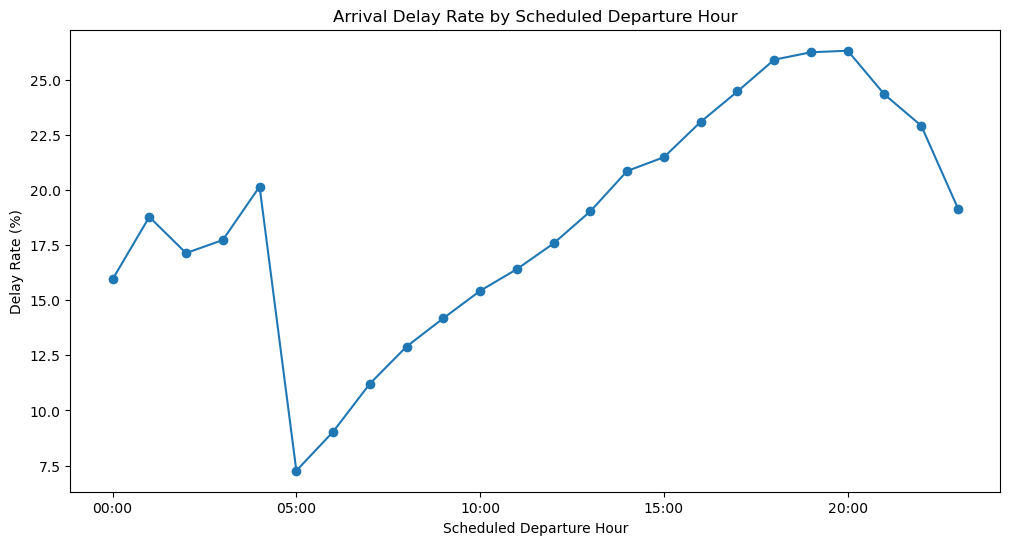

In [112]:
hourly_analysis.plot(
    x="hour_label",
    y="delay_rate",
    kind="line",
    marker="o",
    figsize=(12, 6),
    title="Arrival Delay Rate by Scheduled Departure Hour",
    xlabel="Scheduled Departure Hour",
    ylabel="Delay Rate (%)",
    legend=False
)

In [113]:
day_delay = (
    flights.loc[eligible]
    .assign(
        delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)
    )
    .groupby("DAY_OF_WEEK")["delayed"]
    .agg(["count", "mean"])
)

day_delay["delay_rate"] = day_delay["mean"] * 100

day_delay

,count,mean,delay_rate
DAY_OF_WEEK,,,
1,841794,0.197514,19.751388
2,827399,0.182721,18.272079
3,843242,0.182159,18.215886
4,857886,0.200134,20.013382
5,851387,0.191970,19.197028
6,689745,0.159936,15.993592
7,802555,0.183088,18.308776


In [114]:
month_delay = (
    flights.loc[eligible]
    .assign(
        delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)
    )
    .groupby("MONTH")["delayed"]
    .agg(["count", "mean"])
)

month_delay["delay_rate"] = month_delay["mean"] * 100

month_delay

,count,mean,delay_rate
MONTH,,,
1,457013,0.209952,20.995245
2,407663,0.233475,23.347471
3,492138,0.193954,19.395373
4,479251,0.171616,17.161571
5,489641,0.183083,18.308312
6,492847,0.234844,23.484367
7,514384,0.209235,20.923474
8,503956,0.186748,18.674845
9,462153,0.129959,12.995913


In [115]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_delay["day_name"] = day_delay.index.map(day_names)

day_delay

,count,mean,delay_rate,day_name
DAY_OF_WEEK,,,,
1,841794,0.197514,19.751388,Monday
2,827399,0.182721,18.272079,Tuesday
3,843242,0.182159,18.215886,Wednesday
4,857886,0.200134,20.013382,Thursday
5,851387,0.191970,19.197028,Friday
6,689745,0.159936,15.993592,Saturday
7,802555,0.183088,18.308776,Sunday


In [116]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

month_delay["month_name"] = month_delay.index.map(month_names)

month_delay

,count,mean,delay_rate,month_name
MONTH,,,,
1,457013,0.209952,20.995245,January
2,407663,0.233475,23.347471,February
3,492138,0.193954,19.395373,March
4,479251,0.171616,17.161571,April
5,489641,0.183083,18.308312,May
6,492847,0.234844,23.484367,June
7,514384,0.209235,20.923474,July
8,503956,0.186748,18.674845,August
9,462153,0.129959,12.995913,September


<Axes: title={'center': 'Arrival Delay Rate by Month'}, xlabel='Month', ylabel='Delay Rate (%)'>

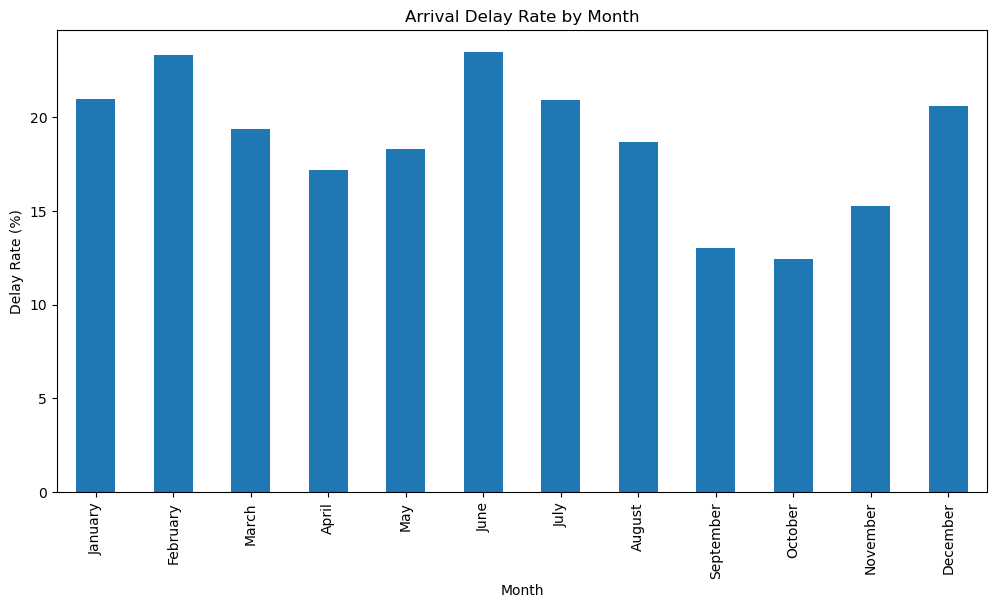

In [117]:
month_delay.plot(
    x="month_name",
    y="delay_rate",
    kind="bar",
    figsize=(12, 6),
    title="Arrival Delay Rate by Month",
    xlabel="Month",
    ylabel="Delay Rate (%)",
    legend=False
)

<Axes: title={'center': 'Arrival Delay Rate by Day of Week'}, xlabel='Day', ylabel='Delay Rate (%)'>

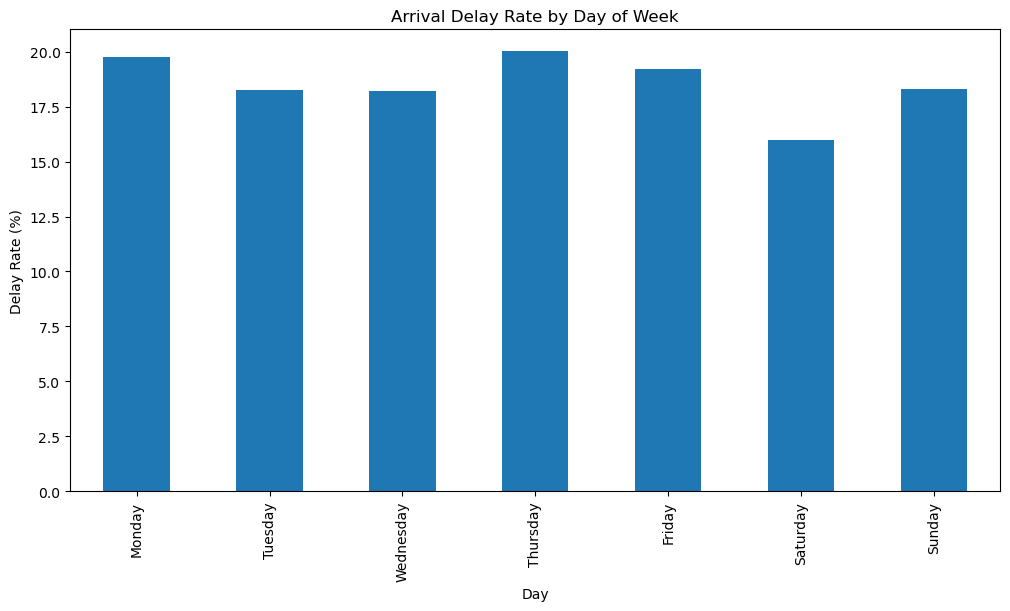

In [118]:
day_delay.plot(
    x="day_name",
    y="delay_rate",
    kind="bar",
    figsize=(12, 6),
    title="Arrival Delay Rate by Day of Week",
    xlabel="Day",
    ylabel="Delay Rate (%)",
    legend=False
)

## Temporal Delay Patterns

AirIntel's 2015 data shows substantial variation in arrival-delay rates by both month and day of week.

Monthly delay rates range from approximately 12.4% in October to 23.5% in June.

Day-of-week delay rates range from approximately 16.0% on Saturday to 20.0% on Thursday.

These are descriptive relationships rather than causal conclusions. Temporal patterns may reflect differences in weather, traffic volume, route schedules, airport congestion, and other operational factors.

AirIntel will later allow the machine-learning model to evaluate these variables jointly.

In [119]:
route = (
    flights["ORIGIN_AIRPORT"].astype(str)
    + " → "
    + flights["DESTINATION_AIRPORT"].astype(str)
)

route.head(10)

0    ANC → SEA
1    LAX → PBI
2    SFO → CLT
3    LAX → MIA
4    SEA → ANC
5    SFO → MSP
6    LAS → MSP
7    LAX → CLT
8    SFO → DFW
9    LAS → ATL
dtype: object

In [120]:
route_counts = (
    route.loc[eligible]
    .value_counts()
    .head(20)
)

route_counts

SFO → LAX    13400
LAX → SFO    13109
JFK → LAX    11853
LAX → JFK    11851
LAS → LAX     9651
LAX → LAS     9522
LGA → ORD     9179
ORD → LGA     9101
SFO → JFK     8306
JFK → SFO     8301
OGG → HNL     8268
HNL → OGG     8246
ATL → MCO     8148
MCO → ATL     8144
LAX → ORD     8131
ATL → LGA     7955
LGA → ATL     7953
SFO → LAS     7945
ORD → LAX     7826
LAS → SFO     7812
Name: count, dtype: int64

In [121]:
route_delay = (
    flights.loc[eligible]
    .assign(
        route=route[eligible],
        delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)
    )
    .groupby("route")["delayed"]
    .agg(["count", "mean"])
)

route_delay["delay_rate"] = route_delay["mean"] * 100

route_delay

,count,mean,delay_rate
route,,,
10135 → 10397,88,0.147727,14.772727
10135 → 11433,75,0.213333,21.333333
10135 → 13930,76,0.157895,15.789474
10136 → 11298,192,0.114583,11.458333
10140 → 10397,91,0.065934,6.593407
...,...,...,...
XNA → SFO,51,0.274510,27.450980
XNA → SLC,1,0.000000,0.000000
YAK → CDV,325,0.129231,12.923077


In [122]:
route_analysis = route_delay[
    route_delay["count"] >= 1000
].sort_values(
    "delay_rate",
    ascending=False
)

route_analysis.head(20)

,count,mean,delay_rate
route,,,
LGA → CMH,1316,0.335866,33.586626
RDU → LGA,1677,0.333930,33.392964
RIC → LGA,1283,0.330475,33.047545
PHL → SJU,1024,0.328125,32.812500
IAH → LAX,4388,0.325433,32.543300
DEN → ASE,1019,0.324828,32.482826
ORD → DEN,5517,0.322639,32.263912
LAS → FLL,1024,0.321289,32.128906
PBI → BOS,1572,0.317430,31.743003


In [123]:
route_analysis.sort_values(
    "delay_rate",
    ascending=True
).head(20)

,count,mean,delay_rate
route,,,
IDA → SLC,1318,0.053111,5.311077
PDX → MSP,1289,0.065167,6.516680
SAN → MSP,1066,0.066604,6.660413
HNL → LIH,5850,0.067350,6.735043
BIL → SLC,1057,0.072848,7.284768
HNL → KOA,6379,0.075247,7.524690
SNA → SLC,1563,0.076775,7.677543
SAN → ATL,2029,0.077871,7.787087
SBA → PHX,1008,0.079365,7.936508


In [124]:
flights["DISTANCE"].describe()

count    5.819079e+06
mean     8.223565e+02
std      6.077843e+02
min      2.100000e+01
25%      3.730000e+02
50%      6.470000e+02
75%      1.062000e+03
max      4.983000e+03
Name: DISTANCE, dtype: float64

In [125]:
flights["SCHEDULED_TIME"].describe()

count    5.819073e+06
mean     1.416859e+02
std      7.521058e+01
min      1.800000e+01
25%      8.500000e+01
50%      1.230000e+02
75%      1.730000e+02
max      7.180000e+02
Name: SCHEDULED_TIME, dtype: float64

In [126]:
distance_bins = pd.cut(
    flights.loc[eligible, "DISTANCE"],
    bins=[0, 500, 1000, 1500, 2000, 3000, 5000],
    labels=[
        "0-500",
        "501-1000",
        "1001-1500",
        "1501-2000",
        "2001-3000",
        "3001+"
    ]
)

distance_delay = (
    flights.loc[eligible]
    .assign(
        distance_band=distance_bins,
        delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)
    )
    .groupby("distance_band", observed=True)["delayed"]
    .agg(["count", "mean"])
)

distance_delay["delay_rate"] = distance_delay["mean"] * 100

distance_delay

,count,mean,delay_rate
distance_band,,,
0-500,2087046,0.181993,18.199311
501-1000,2002895,0.186630,18.662985
1001-1500,846699,0.197136,19.713617
1501-2000,407741,0.183440,18.343998
2001-3000,360173,0.182890,18.288989
3001+,9454,0.235667,23.566744


In [127]:
duration_bins = pd.cut(
    flights.loc[eligible, "SCHEDULED_TIME"],
    bins=[0, 60, 120, 180, 240, 300, 400, 600],
    labels=[
        "0-60",
        "61-120",
        "121-180",
        "181-240",
        "241-300",
        "301-400",
        "401+"
    ]
)

duration_delay = (
    flights.loc[eligible]
    .assign(
        duration_band=duration_bins,
        delayed=(flights.loc[eligible, "ARRIVAL_DELAY"] >= 15).astype(int)
    )
    .groupby("duration_band", observed=True)["delayed"]
    .agg(["count", "mean"])
)

duration_delay["delay_rate"] = duration_delay["mean"] * 100

duration_delay

,count,mean,delay_rate
duration_band,,,
0-60,364011,0.171220,17.122010
61-120,2436460,0.182900,18.290019
121-180,1636297,0.192710,19.271013
181-240,647153,0.192384,19.238418
241-300,315987,0.183207,18.320690
301-400,296980,0.181238,18.123779
401+,16071,0.230788,23.078838


## Distance and Scheduled Duration

AirIntel will evaluate both route distance and scheduled flight duration as potential predictive variables.

These variables describe the planned flight before departure, so they can potentially be used as pre-departure features.

Observed relationships between distance/duration and delay rates are descriptive and do not imply causation.

In [128]:
flights[
    ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]
].describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY
count,5.732926e+06,5.714008e+06
mean,9.370158e+00,4.407057e+00
std,3.708094e+01,3.927130e+01
min,-8.200000e+01,-8.700000e+01
25%,-5.000000e+00,-1.300000e+01
50%,-2.000000e+00,-5.000000e+00
75%,7.000000e+00,8.000000e+00
max,1.988000e+03,1.971000e+03


In [129]:
flights[
    ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]
].corr()

,DEPARTURE_DELAY,ARRIVAL_DELAY
DEPARTURE_DELAY,1.000000,0.944672
ARRIVAL_DELAY,0.944672,1.000000


In [132]:
departure_bins = pd.cut(
    flights.loc[eligible, "DEPARTURE_DELAY"],
    bins=[-float("inf"), 0, 15, 30, 60, 120, float("inf")],
    labels=[
        "Early/On-time",
        "1-15 min",
        "16-30 min",
        "31-60 min",
        "61-120 min",
        "120+ min"
    ]
)

departure_bins.head(10)

0    Early/On-time
1    Early/On-time
2    Early/On-time
3    Early/On-time
4    Early/On-time
5    Early/On-time
6    Early/On-time
7         1-15 min
8    Early/On-time
9         1-15 min
Name: DEPARTURE_DELAY, dtype: category
Categories (6, object): ['Early/On-time' < '1-15 min' < '16-30 min' < '31-60 min' < '61-120 min' < '120+ min']

In [133]:
recovered = (
    (flights.loc[eligible, "DEPARTURE_DELAY"] > 0)
    & (flights.loc[eligible, "ARRIVAL_DELAY"] < 15)
)

print("Late departures that recovered:",
      recovered.sum())

print("Recovery rate:",
      recovered.mean() * 100)

Late departures that recovered: 1164176
Recovery rate: 20.374070179810737


## Departure Delay vs Arrival Delay

Departure delay is strongly relevant to final arrival performance, but it occurs after the pre-departure prediction point used by AirIntel's initial model.

Therefore:

- DEPARTURE_DELAY is retained in the dataset.
- It is used for post-flight analysis and future prediction scenarios.
- It is excluded from the initial pre-departure feature set to avoid data leakage.

AirIntel distinguishes between information available before departure and information observed during/after flight operations.

In [134]:
delay_causes = flights[
    [
        "AIR_SYSTEM_DELAY",
        "SECURITY_DELAY",
        "AIRLINE_DELAY",
        "LATE_AIRCRAFT_DELAY",
        "WEATHER_DELAY"
    ]
].sum()

delay_causes.sort_values(ascending=False)

LATE_AIRCRAFT_DELAY    24961931.0
AIRLINE_DELAY          20172956.0
AIR_SYSTEM_DELAY       14335762.0
WEATHER_DELAY           3100233.0
SECURITY_DELAY            80985.0
dtype: float64

In [135]:
cause_flights = (
    flights[
        [
            "AIR_SYSTEM_DELAY",
            "SECURITY_DELAY",
            "AIRLINE_DELAY",
            "LATE_AIRCRAFT_DELAY",
            "WEATHER_DELAY"
        ]
    ]
    .gt(0)
    .sum()
)

cause_flights.sort_values(ascending=False)

AIRLINE_DELAY          570022
AIR_SYSTEM_DELAY       564826
LATE_AIRCRAFT_DELAY    556953
WEATHER_DELAY           64716
SECURITY_DELAY           3484
dtype: int64

In [136]:
cause_avg_delay = (
    flights[
        [
            "AIR_SYSTEM_DELAY",
            "SECURITY_DELAY",
            "AIRLINE_DELAY",
            "LATE_AIRCRAFT_DELAY",
            "WEATHER_DELAY"
        ]
    ]
    .where(lambda x: x > 0)
    .mean()
    .sort_values(ascending=False)
)

cause_avg_delay

WEATHER_DELAY          47.905201
LATE_AIRCRAFT_DELAY    44.818739
AIRLINE_DELAY          35.389785
AIR_SYSTEM_DELAY       25.380846
SECURITY_DELAY         23.244834
dtype: float64

In [137]:
cause_summary = pd.DataFrame({
    "total_delay_minutes": delay_causes,
    "affected_flights": cause_flights,
    "avg_minutes_when_present": cause_avg_delay
})

cause_summary.sort_values(
    "total_delay_minutes",
    ascending=False
)

,total_delay_minutes,affected_flights,avg_minutes_when_present
LATE_AIRCRAFT_DELAY,24961931.0,556953,44.818739
AIRLINE_DELAY,20172956.0,570022,35.389785
AIR_SYSTEM_DELAY,14335762.0,564826,25.380846
WEATHER_DELAY,3100233.0,64716,47.905201
SECURITY_DELAY,80985.0,3484,23.244834


## Delay Cause Analysis

The BTS flight data contains five delay-cause variables:

- AIR_SYSTEM_DELAY
- SECURITY_DELAY
- AIRLINE_DELAY
- LATE_AIRCRAFT_DELAY
- WEATHER_DELAY

These variables describe observed causes after the flight operation and therefore are not used as features for the initial pre-departure prediction model.

They are retained for AirIntel's post-flight intelligence layer, including:
- delay-cause analysis
- airline performance analysis
- airport analysis
- operational pattern analysis
- model/result interpretation

AirIntel distinguishes between variables used to make a prediction and variables used to explain the outcome after it occurs.

In [138]:
print("Total flights:", len(flights))
print("Normal arrivals:", ((flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)).sum())
print("Cancelled:", (flights["CANCELLED"] == 1).sum())
print("Diverted:", (flights["DIVERTED"] == 1).sum())

Total flights: 5819079
Normal arrivals: 5714008
Cancelled: 89884
Diverted: 15187


In [139]:
normal_flights = (
    (flights["CANCELLED"] == 0)
    & (flights["DIVERTED"] == 0)
)

print("Normal flights:", normal_flights.sum())
print("Flights with ARRIVAL_DELAY:", flights["ARRIVAL_DELAY"].notna().sum())
print(
    "Counts match:",
    normal_flights.sum() == flights["ARRIVAL_DELAY"].notna().sum()
)

Normal flights: 5714008
Flights with ARRIVAL_DELAY: 5714008
Counts match: True


In [140]:
model_population = flights.loc[normal_flights].copy()

print("Model population:", len(model_population))

Model population: 5714008


In [141]:
y = (
    model_population["ARRIVAL_DELAY"] >= 15
).astype(int)

print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

ARRIVAL_DELAY
0    4650569
1    1063439
Name: count, dtype: int64
ARRIVAL_DELAY
0    81.388913
1    18.611087
Name: proportion, dtype: float64


## AirIntel Prediction Scope

AirIntel's initial supervised-learning problem predicts whether a normally operated flight arrives at least 15 minutes late.

Cancelled and diverted flights are excluded from the arrival-delay prediction population because they do not have a normal arrival outcome.

However, the original cancellation and diversion fields are retained in the raw dataset and may be used for separate descriptive and operational analysis.

The raw dataset is never modified or reduced merely to prepare the model.

In [142]:
features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE"
]

X = model_population[features].copy()
y = (model_population["ARRIVAL_DELAY"] >= 15).astype(int)

print(X.shape, y.shape)

(5714008, 9) (5714008,)


In [143]:
X.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE
0,1,1,4,AS,ANC,SEA,0005,205.0,1448
1,1,1,4,AA,LAX,PBI,0010,280.0,2330
2,1,1,4,US,SFO,CLT,0020,286.0,2296
3,1,1,4,AA,LAX,MIA,0020,285.0,2342
4,1,1,4,AS,SEA,ANC,0025,235.0,1448


In [144]:
X.dtypes

MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE     object
SCHEDULED_TIME         float64
DISTANCE                 int64
dtype: object

In [145]:
X["DEP_HOUR"] = (
    X["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
    .str[:2]
    .astype(int)
)

X["DEP_MINUTE"] = (
    X["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
    .str[2:]
    .astype(int)
)

X[["SCHEDULED_DEPARTURE", "DEP_HOUR", "DEP_MINUTE"]].head(10)

,SCHEDULED_DEPARTURE,DEP_HOUR,DEP_MINUTE
0,0005,0,5
1,0010,0,10
2,0020,0,20
3,0020,0,20
4,0025,0,25
5,0025,0,25
6,0025,0,25
7,0030,0,30
8,0030,0,30
9,0030,0,30


In [146]:
X = X.drop(columns=["SCHEDULED_DEPARTURE"])

In [147]:
print("Airlines:", X["AIRLINE"].nunique())
print("Origin airports:", X["ORIGIN_AIRPORT"].nunique())
print("Destination airports:", X["DESTINATION_AIRPORT"].nunique())

Airlines: 14
Origin airports: 628
Destination airports: 629


In [148]:
print(X.columns.tolist())

['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_TIME', 'DISTANCE', 'DEP_HOUR', 'DEP_MINUTE']


In [149]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values:")
print(X.isna().sum())

X shape: (5714008, 10)
y shape: (5714008,)

Missing values:
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_TIME         0
DISTANCE               0
DEP_HOUR               0
DEP_MINUTE             0
dtype: int64


In [150]:
dates = pd.to_datetime(
    dict(
        year=model_population["YEAR"],
        month=model_population["MONTH"],
        day=model_population["DAY"]
    )
)

print(dates.min())
print(dates.max())

2015-01-01 00:00:00
2015-12-31 00:00:00


In [151]:
cutoff_date = dates.quantile(0.80)

train_mask = dates <= cutoff_date
test_mask = dates > cutoff_date

print("Cutoff:", cutoff_date)
print("Training rows:", train_mask.sum())
print("Test rows:", test_mask.sum())

Cutoff: 2015-10-18 00:00:00
Training rows: 4581516
Test rows: 1132492


In [152]:
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4581516, 10)
X_test : (1132492, 10)
y_train: (4581516,)
y_test : (1132492,)


In [153]:
categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

numerical_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_TIME",
    "DISTANCE",
    "DEP_HOUR",
    "DEP_MINUTE"
]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
Numerical: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_TIME', 'DISTANCE', 'DEP_HOUR', 'DEP_MINUTE']


In [155]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [156]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_accuracy = baseline.score(X_test, y_test)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.8297948241576982


In [157]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (4581516, 1275)
Processed test shape: (1132492, 1275)


In [158]:
print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 10
Processed features: 1275


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1
)

logistic_model.fit(X_train_processed, y_train)


f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [162]:
y_pred = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred[:20])


y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("First 20 delay probabilities:")
print(y_prob[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
First 20 delay probabilities:
[0.10429476 0.10205999 0.13880586 0.11952939 0.12818245 0.10143362
 0.09662941 0.12677169 0.11765026 0.09609765 0.11471231 0.1242264
 0.09843258 0.11042023 0.08793001 0.09427947 0.12882472 0.09176168
 0.08114622 0.09319668]


In [163]:
y_pred = logistic_model.predict(X_test_processed)
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("First 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 probabilities:")
print(y_prob[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 probabilities:
[0.10429476 0.10205999 0.13880586 0.11952939 0.12818245 0.10143362
 0.09662941 0.12677169 0.11765026 0.09609765 0.11471231 0.1242264
 0.09843258 0.11042023 0.08793001 0.09427947 0.12882472 0.09176168
 0.08114622 0.09319668]


In [164]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression accuracy:", logistic_accuracy)

Logistic Regression accuracy: 0.8297948241576982


In [165]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[939736      0]
 [192756      0]]


In [166]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Delayed", "Delayed"]
    )
)

f:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

 Not Delayed       0.83      1.00      0.91    939736
     Delayed       0.00      0.00      0.00    192756

    accuracy                           0.83   1132492
   macro avg       0.41      0.50      0.45   1132492
weighted avg       0.69      0.83      0.75   1132492



f:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [167]:
print("Baseline accuracy:", baseline_accuracy)
print("Logistic Regression accuracy:", logistic_accuracy)

Baseline accuracy: 0.8297948241576982
Logistic Regression accuracy: 0.8297948241576982


In [168]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Delayed", "Delayed"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.83      1.00      0.91    939736
     Delayed       0.00      0.00      0.00    192756

    accuracy                           0.83   1132492
   macro avg       0.41      0.50      0.45   1132492
weighted avg       0.69      0.83      0.75   1132492



In [169]:
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

Minimum probability: 0.013049807562738752
Maximum probability: 0.4471096455807756
Mean probability: 0.11932374686668867


In [170]:
print("Probability >= 0.20:",
      (y_prob >= 0.20).sum())

print("Probability >= 0.30:",
      (y_prob >= 0.30).sum())

print("Probability >= 0.40:",
      (y_prob >= 0.40).sum())

Probability >= 0.20: 49199
Probability >= 0.30: 533
Probability >= 0.40: 2


In [171]:
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())
print("Mean probability:", y_prob.mean())

Minimum probability: 0.013049807562738752
Maximum probability: 0.4471096455807756
Mean probability: 0.11932374686668867


In [172]:
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    print(
        f"Threshold {threshold:.2f}:",
        (y_prob >= threshold).sum()
    )

Threshold 0.10: 725634
Threshold 0.20: 49199
Threshold 0.30: 533
Threshold 0.40: 2
Threshold 0.50: 0


In [173]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.522319189877301


In [174]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)
print("Baseline PR-AUC:", y_test.mean())

PR-AUC: 0.1798818321971592
Baseline PR-AUC: 0.17020517584230174


In [175]:
print("Iterations used:", logistic_model.n_iter_)

Iterations used: [100]


In [176]:
print("Number of coefficients:",
      len(logistic_model.coef_[0]))

print("Largest absolute coefficients:")

import numpy as np

top_indices = np.argsort(
    np.abs(logistic_model.coef_[0])
)[-15:]

print(logistic_model.coef_[0][top_indices])

Number of coefficients: 1275
Largest absolute coefficients:
[-0.05380328  0.05646671 -0.05735864  0.05917867 -0.06238762  0.06749002
  0.06752368 -0.06753865 -0.06832372  0.07130032 -0.07803272 -0.07921809
 -0.09527082 -0.10316504 -0.20959438]


In [177]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names[:30])

Number of feature names: 1275
['categorical__AIRLINE_AA' 'categorical__AIRLINE_AS'
 'categorical__AIRLINE_B6' 'categorical__AIRLINE_DL'
 'categorical__AIRLINE_EV' 'categorical__AIRLINE_F9'
 'categorical__AIRLINE_HA' 'categorical__AIRLINE_MQ'
 'categorical__AIRLINE_NK' 'categorical__AIRLINE_OO'
 'categorical__AIRLINE_UA' 'categorical__AIRLINE_US'
 'categorical__AIRLINE_VX' 'categorical__AIRLINE_WN'
 'categorical__ORIGIN_AIRPORT_10135' 'categorical__ORIGIN_AIRPORT_10136'
 'categorical__ORIGIN_AIRPORT_10140' 'categorical__ORIGIN_AIRPORT_10141'
 'categorical__ORIGIN_AIRPORT_10146' 'categorical__ORIGIN_AIRPORT_10154'
 'categorical__ORIGIN_AIRPORT_10155' 'categorical__ORIGIN_AIRPORT_10157'
 'categorical__ORIGIN_AIRPORT_10158' 'categorical__ORIGIN_AIRPORT_10165'
 'categorical__ORIGIN_AIRPORT_10170' 'categorical__ORIGIN_AIRPORT_10185'
 'categorical__ORIGIN_AIRPORT_10208' 'categorical__ORIGIN_AIRPORT_10257'
 'categorical__ORIGIN_AIRPORT_10268' 'categorical__ORIGIN_AIRPORT_10279']


In [178]:
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

coef_table.sort_values(
    "abs_coefficient",
    ascending=False
).head(20)

,feature,coefficient,abs_coefficient
3,categorical__AIRLINE_DL,-0.209594,0.209594
13,categorical__AIRLINE_WN,-0.103165,0.103165
1268,remainder__MONTH,-0.095271,0.095271
1,categorical__AIRLINE_AS,-0.079218,0.079218
1270,remainder__DAY_OF_WEEK,-0.078033,0.078033
547,categorical__ORIGIN_AIRPORT_ORD,0.071300,0.071300
9,categorical__AIRLINE_OO,-0.068324,0.068324
966,categorical__DESTINATION_AIRPORT_ATL,-0.067539,0.067539
10,categorical__AIRLINE_UA,0.067524,0.067524
8,categorical__AIRLINE_NK,0.067490,0.067490


In [179]:
coef_table.sort_values(
    "coefficient",
    ascending=False
).head(15)

,feature,coefficient,abs_coefficient
547,categorical__ORIGIN_AIRPORT_ORD,0.071300,0.071300
10,categorical__AIRLINE_UA,0.067524,0.067524
8,categorical__AIRLINE_NK,0.067490,0.067490
1174,categorical__DESTINATION_AIRPORT_ORD,0.059179,0.059179
501,categorical__ORIGIN_AIRPORT_LGA,0.056467,0.056467
1122,categorical__DESTINATION_AIRPORT_LAX,0.053012,0.053012
2,categorical__AIRLINE_B6,0.044397,0.044397
485,categorical__ORIGIN_AIRPORT_JFK,0.044106,0.044106
1128,categorical__DESTINATION_AIRPORT_LGA,0.042864,0.042864
1273,remainder__DEP_HOUR,0.042071,0.042071


In [180]:
coef_table.sort_values(
    "coefficient",
    ascending=True
).head(15)

,feature,coefficient,abs_coefficient
3,categorical__AIRLINE_DL,-0.209594,0.209594
13,categorical__AIRLINE_WN,-0.103165,0.103165
1268,remainder__MONTH,-0.095271,0.095271
1,categorical__AIRLINE_AS,-0.079218,0.079218
1270,remainder__DAY_OF_WEEK,-0.078033,0.078033
9,categorical__AIRLINE_OO,-0.068324,0.068324
966,categorical__DESTINATION_AIRPORT_ATL,-0.067539,0.067539
339,categorical__ORIGIN_AIRPORT_ATL,-0.062388,0.062388
6,categorical__AIRLINE_HA,-0.057359,0.057359
605,categorical__ORIGIN_AIRPORT_SLC,-0.053803,0.053803


## Baseline Logistic Regression — Initial Findings

The initial Logistic Regression model achieved approximately:

- Accuracy: 82.98%
- ROC-AUC: 0.5223
- PR-AUC: 0.1799
- Baseline PR-AUC: 0.1702

The accuracy is approximately equal to the majority-class baseline, while ROC-AUC indicates weak ranking performance.

PR-AUC is slightly above the positive-class prevalence baseline, indicating that the model has learned a small amount of predictive signal.

This suggests that the initial feature set contains useful information but does not sufficiently capture the operational factors influencing individual flight delays.

Next, AirIntel will investigate feature engineering and richer historical/operational signals rather than selecting a more complex model immediately.

In [181]:
coef_table[
    coef_table["feature"].str.contains("DEP_HOUR")
]

,feature,coefficient,abs_coefficient
1273,remainder__DEP_HOUR,0.042071,0.042071


In [182]:
coef_table[
    coef_table["feature"].str.contains(
        "DISTANCE|SCHEDULED_TIME"
    )
]

,feature,coefficient,abs_coefficient
1271,remainder__SCHEDULED_TIME,-0.014822,0.014822
1272,remainder__DISTANCE,0.001676,0.001676


In [183]:
X["DAY_OF_WEEK_SIN"] = np.sin(
    2 * np.pi * X["DAY_OF_WEEK"] / 7
)

X["DAY_OF_WEEK_COS"] = np.cos(
    2 * np.pi * X["DAY_OF_WEEK"] / 7
)

In [186]:
X["DEP_HOUR_SIN"] = np.sin(2 * np.pi * X["DEP_HOUR"] / 24)
X["DEP_HOUR_COS"] = np.cos(2 * np.pi * X["DEP_HOUR"] / 24)

X["DAY_OF_WEEK_SIN"] = np.sin(2 * np.pi * X["DAY_OF_WEEK"] / 7)
X["DAY_OF_WEEK_COS"] = np.cos(2 * np.pi * X["DAY_OF_WEEK"] / 7)

In [187]:
numerical_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_TIME",
    "DISTANCE",
    "DEP_HOUR",
    "DEP_MINUTE",
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS"
]

In [189]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)      

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(4581516, 1275)
(1132492, 1275)


In [190]:
logistic_model_v2 = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1
)

logistic_model_v2.fit(X_train_processed, y_train)

y_prob_v2 = logistic_model_v2.predict_proba(X_test_processed)[:, 1]

f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [191]:
roc_auc_v2 = roc_auc_score(y_test, y_prob_v2)

print("V1 ROC-AUC:", roc_auc)
print("V2 ROC-AUC:", roc_auc_v2)

V1 ROC-AUC: 0.522319189877301
V2 ROC-AUC: 0.5223194292284066


In [192]:
X[
    [
        "DEP_HOUR",
        "DEP_HOUR_SIN",
        "DEP_HOUR_COS",
        "DAY_OF_WEEK",
        "DAY_OF_WEEK_SIN",
        "DAY_OF_WEEK_COS"
    ]
].head(10)

,DEP_HOUR,DEP_HOUR_SIN,DEP_HOUR_COS,DAY_OF_WEEK,DAY_OF_WEEK_SIN,DAY_OF_WEEK_COS
0,0,0.0,1.0,4,-0.433884,-0.900969
1,0,0.0,1.0,4,-0.433884,-0.900969
2,0,0.0,1.0,4,-0.433884,-0.900969
3,0,0.0,1.0,4,-0.433884,-0.900969
4,0,0.0,1.0,4,-0.433884,-0.900969
5,0,0.0,1.0,4,-0.433884,-0.900969
6,0,0.0,1.0,4,-0.433884,-0.900969
7,0,0.0,1.0,4,-0.433884,-0.900969
8,0,0.0,1.0,4,-0.433884,-0.900969
9,0,0.0,1.0,4,-0.433884,-0.900969


In [193]:
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4581516, 14)
X_test : (1132492, 14)
y_train: (4581516,)
y_test : (1132492,)


In [195]:
preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_processed_v2 = preprocessor_v2.fit_transform(X_train)
X_test_processed_v2 = preprocessor_v2.transform(X_test)

print("Train:", X_train_processed_v2.shape)
print("Test :", X_test_processed_v2.shape)

Train: (4581516, 1279)
Test : (1132492, 1279)


In [196]:
logistic_model_v2 = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1
)

logistic_model_v2.fit(
    X_train_processed_v2,
    y_train
)

y_prob_v2 = logistic_model_v2.predict_proba(
    X_test_processed_v2
)[:, 1]

f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [197]:
roc_auc_v2 = roc_auc_score(y_test, y_prob_v2)
pr_auc_v2 = average_precision_score(y_test, y_prob_v2)

print("V1 ROC-AUC:", roc_auc)
print("V2 ROC-AUC:", roc_auc_v2)

print("\nV1 PR-AUC:", pr_auc)
print("V2 PR-AUC:", pr_auc_v2)

V1 ROC-AUC: 0.522319189877301
V2 ROC-AUC: 0.5223194292284066

V1 PR-AUC: 0.1798818321971592
V2 PR-AUC: 0.17988220884323325


In [201]:
import numpy as np
import pandas as pd

X_v3 = model_population[
    [
        "MONTH",
        "DAY_OF_WEEK",
        "AIRLINE",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "SCHEDULED_TIME",
        "DISTANCE",
        "SCHEDULED_DEPARTURE"
    ]
].copy()

X_v3["DEP_HOUR"] = (
    X_v3["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
    .str[:2]
    .astype(int)
)

X_v3 = X_v3.drop(columns="SCHEDULED_DEPARTURE")

y_v3 = (
    model_population["ARRIVAL_DELAY"] >= 15
).astype(int)

print("X_v3:", X_v3.shape)
print("y_v3:", y_v3.shape)

X_v3: (5714008, 8)
y_v3: (5714008,)


In [202]:
X_train_v3 = X_v3.loc[train_mask]
X_test_v3 = X_v3.loc[test_mask]

y_train_v3 = y_v3.loc[train_mask]
y_test_v3 = y_v3.loc[test_mask]

print("X_train_v3:", X_train_v3.shape)
print("X_test_v3 :", X_test_v3.shape)
print("y_train_v3:", y_train_v3.shape)
print("y_test_v3 :", y_test_v3.shape)

X_train_v3: (4581516, 8)
X_test_v3 : (1132492, 8)
y_train_v3: (4581516,)
y_test_v3 : (1132492,)


In [203]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_v3 = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR"
]

preprocessor_v3 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_v3
        )
    ],
    remainder="passthrough"
)

X_train_processed_v3 = preprocessor_v3.fit_transform(X_train_v3)
X_test_processed_v3 = preprocessor_v3.transform(X_test_v3)

print("Processed train:", X_train_processed_v3.shape)
print("Processed test :", X_test_processed_v3.shape)

Processed train: (4581516, 1311)
Processed test : (1132492, 1311)


In [204]:
from sklearn.linear_model import LogisticRegression

logistic_model_v3 = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1
)

logistic_model_v3.fit(
    X_train_processed_v3,
    y_train_v3
)

print("V3 model trained successfully.")

V3 model trained successfully.


f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [205]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob_v3 = logistic_model_v3.predict_proba(
    X_test_processed_v3
)[:, 1]

roc_auc_v3 = roc_auc_score(y_test_v3, y_prob_v3)
pr_auc_v3 = average_precision_score(y_test_v3, y_prob_v3)

print("V3 probability rows:", len(y_prob_v3))
print("V3 ROC-AUC:", roc_auc_v3)
print("V3 PR-AUC:", pr_auc_v3)

V3 probability rows: 1132492
V3 ROC-AUC: 0.5514234292101043
V3 PR-AUC: 0.19686931911935363


In [206]:
print("Iterations used:", logistic_model_v3.n_iter_)

Iterations used: [100]


In [207]:
X_train_v3[["SCHEDULED_TIME", "DISTANCE"]].describe()

,SCHEDULED_TIME,DISTANCE
count,4.581516e+06,4.581516e+06
mean,1.415095e+02,8.233484e+02
std,7.518016e+01,6.087091e+02
min,1.800000e+01,3.100000e+01
25%,8.500000e+01,3.730000e+02
50%,1.220000e+02,6.470000e+02
75%,1.730000e+02,1.065000e+03
max,7.180000e+02,4.983000e+03


In [208]:
from sklearn.preprocessing import StandardScaler

preprocessor_v4 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_v3
        ),
        (
            "numerical",
            StandardScaler(),
            ["SCHEDULED_TIME", "DISTANCE"]
        )
    ]
)

In [210]:
X_train_processed_v4 = preprocessor_v4.fit_transform(X_train_v3)
X_test_processed_v4 = preprocessor_v4.transform(X_test_v3)

print("Train:", X_train_processed_v4.shape)
print("Test :", X_test_processed_v4.shape)

logistic_model_v4 = LogisticRegression(
    max_iter=300,
    solver="saga",
    n_jobs=-1
)

logistic_model_v4.fit(
    X_train_processed_v4,
    y_train_v3
)

print("Iterations:", logistic_model_v4.n_iter_)

Train: (4581516, 1311)
Test : (1132492, 1311)
Iterations: [300]


f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [211]:
y_prob_v4 = logistic_model_v4.predict_proba(
    X_test_processed_v4
)[:, 1]

roc_auc_v4 = roc_auc_score(y_test_v3, y_prob_v4)
pr_auc_v4 = average_precision_score(y_test_v3, y_prob_v4)

print("V4 ROC-AUC:", roc_auc_v4)
print("V4 PR-AUC:", pr_auc_v4)

V4 ROC-AUC: 0.6134390026012037
V4 PR-AUC: 0.23571354947232853


In [212]:
y_pred_v4 = logistic_model_v4.predict(X_test_processed_v4)

accuracy_v4 = accuracy_score(y_test_v3, y_pred_v4)

print("Accuracy:", accuracy_v4)

Accuracy: 0.826480893463265


In [213]:
print(
    classification_report(
        y_test_v3,
        y_pred_v4,
        target_names=["Not Delayed", "Delayed"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.83      0.99      0.90    939736
     Delayed       0.33      0.02      0.03    192756

    accuracy                           0.83   1132492
   macro avg       0.58      0.51      0.47   1132492
weighted avg       0.75      0.83      0.76   1132492



In [214]:
print("Min:", y_prob_v4.min())
print("Max:", y_prob_v4.max())
print("Mean:", y_prob_v4.mean())

Min: 0.006864352936745551
Max: 0.7363395271823099
Mean: 0.23838216875723953


In [215]:
print("Actual delay rate:", y_test_v3.mean())

Actual delay rate: 0.17020517584230174


In [216]:
y_pred_30 = (y_prob_v4 >= 0.30).astype(int)

print(
    classification_report(
        y_test_v3,
        y_pred_30,
        target_names=["Not Delayed", "Delayed"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.86      0.72      0.79    939736
     Delayed       0.24      0.43      0.31    192756

    accuracy                           0.67   1132492
   macro avg       0.55      0.58      0.55   1132492
weighted avg       0.76      0.67      0.71   1132492



In [217]:
y_pred_20 = (y_prob_v4 >= 0.20).astype(int)

print(
    classification_report(
        y_test_v3,
        y_pred_20,
        target_names=["Not Delayed", "Delayed"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Delayed       0.88      0.43      0.58    939736
     Delayed       0.21      0.73      0.32    192756

    accuracy                           0.48   1132492
   macro avg       0.55      0.58      0.45   1132492
weighted avg       0.77      0.48      0.53   1132492



In [218]:
for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    predictions = (y_prob_v4 >= threshold).astype(int)
    print(
        f"Threshold {threshold:.2f}: "
        f"{predictions.sum():,} flights flagged"
    )

Threshold 0.10: 1,006,572 flights flagged
Threshold 0.15: 851,955 flights flagged
Threshold 0.20: 678,630 flights flagged
Threshold 0.25: 500,075 flights flagged
Threshold 0.30: 342,613 flights flagged
Threshold 0.35: 200,333 flights flagged
Threshold 0.40: 92,028 flights flagged
Threshold 0.50: 10,755 flights flagged


In [219]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    predictions = (y_prob_v4 >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test_v3, predictions, zero_division=0),
        "recall": recall_score(y_test_v3, predictions, zero_division=0),
        "f1": f1_score(y_test_v3, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results


,threshold,precision,recall,f1
0,0.10,0.179400,0.936827,0.301134
1,0.15,0.191512,0.846459,0.312354
2,0.20,0.206714,0.727770,0.321974
3,0.25,0.224780,0.583157,0.324486
4,0.30,0.242232,0.430555,0.310037
5,0.35,0.259408,0.269605,0.264408
6,0.40,0.280045,0.133703,0.180993
7,0.50,0.325523,0.018163,0.034406


In [220]:
best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold

threshold    0.250000
precision    0.224780
recall       0.583157
f1           0.324486
Name: 3, dtype: float64

<Axes: title={'center': 'AirIntel Threshold Trade-off'}, xlabel='Decision Threshold', ylabel='Score'>

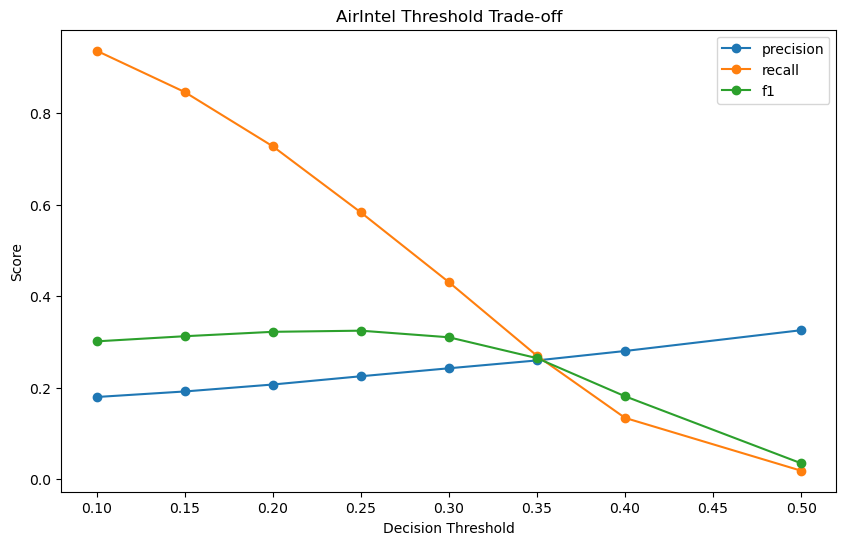

In [221]:
threshold_results.plot(
    x="threshold",
    y=["precision", "recall", "f1"],
    marker="o",
    figsize=(10, 6),
    title="AirIntel Threshold Trade-off",
    xlabel="Decision Threshold",
    ylabel="Score"
)

## Decision Threshold Analysis

The Logistic Regression model produces a probability of arrival delay for each flight.

The probability itself is continuous. A separate decision threshold converts that probability into a binary classification.

A lower threshold catches more delayed flights but produces more false positives. A higher threshold produces fewer alerts but misses more delayed flights.

AirIntel will not assume that 0.50 is the optimal operational threshold. The final threshold will be selected based on the intended use case and the trade-off between precision and recall.

In [222]:
airline_history = (
    pd.DataFrame({
        "AIRLINE": X_train["AIRLINE"],
        "DELAYED": y_train
    })
    .groupby("AIRLINE")["DELAYED"]
    .agg(["mean", "count"])
    .reset_index()
)

airline_history["delay_rate"] = airline_history["mean"]

airline_history

,AIRLINE,mean,count,delay_rate
0,AA,0.187443,532920,0.187443
1,AS,0.129471,137228,0.129471
2,B6,0.227562,208299,0.227562
3,DL,0.139158,696740,0.139158
4,EV,0.200079,452151,0.200079
5,F9,0.267408,71086,0.267408
6,HA,0.125227,61169,0.125227
7,MQ,0.231715,230438,0.231715
8,NK,0.307575,90456,0.307575
9,OO,0.184572,464188,0.184572


In [223]:
airline_history = airline_history[
    ["AIRLINE", "delay_rate", "count"]
].rename(
    columns={"count": "training_flights"}
)

airline_history

,AIRLINE,delay_rate,training_flights
0,AA,0.187443,532920
1,AS,0.129471,137228
2,B6,0.227562,208299
3,DL,0.139158,696740
4,EV,0.200079,452151
5,F9,0.267408,71086
6,HA,0.125227,61169
7,MQ,0.231715,230438
8,NK,0.307575,90456
9,OO,0.184572,464188


In [225]:
X_train_fe = X_train.merge(
    airline_history[
        ["AIRLINE", "delay_rate"]
    ],
    on="AIRLINE",
    how="left"
)


X_test_fe = X_test.merge(
    airline_history[
        ["AIRLINE", "delay_rate"]
    ],
    on="AIRLINE",
    how="left"
)

In [226]:
X_train_fe[
    ["AIRLINE", "delay_rate"]
].head(10)

,AIRLINE,delay_rate
0,AS,0.129471
1,AA,0.187443
2,US,0.188181
3,AA,0.187443
4,AS,0.129471
5,DL,0.139158
6,NK,0.307575
7,US,0.188181
8,AA,0.187443
9,DL,0.139158


In [227]:
airport_history = (
    pd.DataFrame({
        "ORIGIN_AIRPORT": X_train["ORIGIN_AIRPORT"],
        "DELAYED": y_train
    })
    .groupby("ORIGIN_AIRPORT")["DELAYED"]
    .mean()
    .reset_index(name="origin_delay_rate")
)

In [228]:
destination_history = (
    pd.DataFrame({
        "DESTINATION_AIRPORT": X_train["DESTINATION_AIRPORT"],
        "DELAYED": y_train
    })
    .groupby("DESTINATION_AIRPORT")["DELAYED"]
    .mean()
    .reset_index(name="destination_delay_rate")
)

In [229]:
route_history = (
    pd.DataFrame({
        "ORIGIN_AIRPORT": X_train["ORIGIN_AIRPORT"],
        "DESTINATION_AIRPORT": X_train["DESTINATION_AIRPORT"],
        "DELAYED": y_train
    })
    .groupby(
        ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
    )["DELAYED"]
    .mean()
    .reset_index(name="route_delay_rate")
)

In [230]:
for df in [X_train_fe, X_test_fe]:
    df.merge(airport_history, on="ORIGIN_AIRPORT", how="left")

In [231]:
X_train_fe = (
    X_train_fe
    .merge(airport_history, on="ORIGIN_AIRPORT", how="left")
    .merge(destination_history, on="DESTINATION_AIRPORT", how="left")
    .merge(
        route_history,
        on=["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"],
        how="left"
    )
)

X_test_fe = (
    X_test_fe
    .merge(airport_history, on="ORIGIN_AIRPORT", how="left")
    .merge(destination_history, on="DESTINATION_AIRPORT", how="left")
    .merge(
        route_history,
        on=["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"],
        how="left"
    )
)

In [232]:
X_train_fe[
    [
        "AIRLINE",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "delay_rate",
        "origin_delay_rate",
        "destination_delay_rate",
        "route_delay_rate"
    ]
].head()

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,delay_rate,origin_delay_rate,destination_delay_rate,route_delay_rate
0,AS,ANC,SEA,0.129471,0.121133,0.160632,0.097245
1,AA,LAX,PBI,0.187443,0.212954,0.233474,0.298701
2,US,SFO,CLT,0.188181,0.200624,0.160721,0.125085
3,AA,LAX,MIA,0.187443,0.212954,0.211765,0.222449
4,AS,SEA,ANC,0.129471,0.163061,0.177496,0.176785


In [233]:
global_delay_rate = y_train.mean()

history_features = [
    "delay_rate",
    "origin_delay_rate",
    "destination_delay_rate",
    "route_delay_rate"
]

for col in history_features:
    X_train_fe[col] = X_train_fe[col].fillna(global_delay_rate)
    X_test_fe[col] = X_test_fe[col].fillna(global_delay_rate)

In [234]:
categorical_fe = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR"
]

numerical_fe = [
    "SCHEDULED_TIME",
    "DISTANCE",
    "delay_rate",
    "origin_delay_rate",
    "destination_delay_rate",
    "route_delay_rate"
]

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_fe),
        ("numerical", StandardScaler(), numerical_fe)
    ]
)

In [235]:
X_train_processed_fe = preprocessor_fe.fit_transform(X_train_fe)
X_test_processed_fe = preprocessor_fe.transform(X_test_fe)

logistic_model_fe = LogisticRegression(
    max_iter=300,
    solver="saga",
    n_jobs=-1
)

logistic_model_fe.fit(X_train_processed_fe, y_train)

f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,300
,multi_class,'deprecated'


In [236]:
y_prob_fe = logistic_model_fe.predict_proba(X_test_processed_fe)[:, 1]

roc_auc_fe = roc_auc_score(y_test, y_prob_fe)
pr_auc_fe = average_precision_score(y_test, y_prob_fe)

print("ROC-AUC:", roc_auc_fe)
print("PR-AUC:", pr_auc_fe)

ROC-AUC: 0.6156974055720794
PR-AUC: 0.23825989338973952


In [237]:
print("Previous ROC-AUC:", 0.6134390026012037)
print("New ROC-AUC:     ", roc_auc_fe)

print("Previous PR-AUC:", 0.23571354947232853)
print("New PR-AUC:     ", pr_auc_fe)

Previous ROC-AUC: 0.6134390026012037
New ROC-AUC:      0.6156974055720794
Previous PR-AUC: 0.23571354947232853
New PR-AUC:      0.23825989338973952


In [238]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [241]:
categorical_tree = [
    "AIRLINE"
]

numerical_tree = [
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "delay_rate",
    "origin_delay_rate",
    "destination_delay_rate",
    "route_delay_rate"
]

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            categorical_tree
        )
    ],
    remainder="passthrough"
)

tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.08,
                max_leaf_nodes=31,
                random_state=42
            )
        )
    ]
)


In [242]:
tree_model.fit(X_train_fe, y_train)

y_prob_tree = tree_model.predict_proba(X_test_fe)[:, 1]

ValueError: could not convert string to float: 'ANC'

In [ ]:
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)
pr_auc_tree = average_precision_score(y_test, y_prob_tree)

print("Logistic ROC-AUC:", roc_auc_fe)
print("Tree ROC-AUC:    ", roc_auc_tree)

print("Logistic PR-AUC:", pr_auc_fe)
print("Tree PR-AUC:    ", pr_auc_tree)

In [243]:
categorical_tree = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

numerical_tree = [
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "delay_rate",
    "origin_delay_rate",
    "destination_delay_rate",
    "route_delay_rate"
]

In [244]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_tree
        )
    ],
    remainder="passthrough"
)

tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.08,
                max_leaf_nodes=31,
                random_state=42
            )
        )
    ]
)

In [245]:
tree_model.fit(X_train_fe, y_train)

y_prob_tree = tree_model.predict_proba(X_test_fe)[:, 1]

roc_auc_tree = roc_auc_score(y_test, y_prob_tree)
pr_auc_tree = average_precision_score(y_test, y_prob_tree)

print("Logistic ROC-AUC:", roc_auc_fe)
print("Tree ROC-AUC:    ", roc_auc_tree)

print("Logistic PR-AUC:", pr_auc_fe)
print("Tree PR-AUC:    ", pr_auc_tree)

Logistic ROC-AUC: 0.6156974055720794
Tree ROC-AUC:     0.5928078762296854
Logistic PR-AUC: 0.23825989338973952
Tree PR-AUC:     0.2164743467680759


In [246]:
X_train_fe["AIRLINE_DEP_HOUR"] = (
    X_train_fe["AIRLINE"].astype(str)
    + "_" +
    X_train_fe["DEP_HOUR"].astype(str)
)

X_test_fe["AIRLINE_DEP_HOUR"] = (
    X_test_fe["AIRLINE"].astype(str)
    + "_" +
    X_test_fe["DEP_HOUR"].astype(str)
)

In [249]:
categorical_fe2 = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_HOUR",
    "AIRLINE_DEP_HOUR"
]

In [247]:
numerical_fe2 = [
    "SCHEDULED_TIME",
    "DISTANCE",
    "delay_rate",
    "origin_delay_rate",
    "destination_delay_rate",
    "route_delay_rate"
]

In [250]:
preprocessor_fe2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_fe2
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_fe2
        )
    ]
)

logistic_model_fe2 = LogisticRegression(
    max_iter=300,
    solver="saga",
    n_jobs=-1
)

In [251]:
X_train_processed_fe2 = preprocessor_fe2.fit_transform(X_train_fe)
X_test_processed_fe2 = preprocessor_fe2.transform(X_test_fe)

logistic_model_fe2.fit(X_train_processed_fe2, y_train)

y_prob_fe2 = logistic_model_fe2.predict_proba(
    X_test_processed_fe2
)[:, 1]

f:\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [252]:
roc_auc_fe2 = roc_auc_score(y_test, y_prob_fe2)
pr_auc_fe2 = average_precision_score(y_test, y_prob_fe2)

print("Previous ROC-AUC:", roc_auc_fe)
print("New ROC-AUC:     ", roc_auc_fe2)

print("Previous PR-AUC:", pr_auc_fe)
print("New PR-AUC:     ", pr_auc_fe2)

Previous ROC-AUC: 0.6156974055720794
New ROC-AUC:      0.6206993990435024
Previous PR-AUC: 0.23825989338973952
New PR-AUC:      0.24216127196984083


In [253]:
threshold_results_final = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred = (y_prob_fe2 >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    threshold_results_final.append(
        [threshold, precision, recall, f1, y_pred.sum()]
    )

threshold_table_final = pd.DataFrame(
    threshold_results_final,
    columns=[
        "threshold",
        "precision",
        "recall",
        "f1",
        "flagged_flights"
    ]
)

threshold_table_final

,threshold,precision,recall,f1,flagged_flights
0,0.10,0.182011,0.933486,0.304626,988596
1,0.15,0.194211,0.845271,0.315851,838939
2,0.20,0.208981,0.732086,0.325146,675247
3,0.25,0.225102,0.603888,0.327957,517112
4,0.30,0.242195,0.457962,0.316832,364479
5,0.35,0.261621,0.312883,0.284965,230524
6,0.40,0.284356,0.185379,0.224440,125663
7,0.45,0.311810,0.092521,0.142700,57195
8,0.50,0.333625,0.039573,0.070754,22864


In [254]:
threshold_table_final.loc[
    threshold_table_final["f1"].idxmax()
]

threshold               0.250000
precision               0.225102
recall                  0.603888
f1                      0.327957
flagged_flights    517112.000000
Name: 3, dtype: float64

In [255]:
feature_names_final = preprocessor_fe2.get_feature_names_out()

coef_table_final = pd.DataFrame({
    "feature": feature_names_final,
    "coefficient": logistic_model_fe2.coef_[0]
})

coef_table_final["abs_coefficient"] = coef_table_final["coefficient"].abs()

print("Top features increasing delay risk:")
display(
    coef_table_final
    .sort_values("coefficient", ascending=False)
    .head(15)
)

print("Top features decreasing delay risk:")
display(
    coef_table_final
    .sort_values("coefficient", ascending=True)
    .head(15)
)

Top features increasing delay risk:


,feature,coefficient,abs_coefficient
1601,categorical__AIRLINE_DEP_HOUR_WN_23,1.797157,1.797157
1178,categorical__DESTINATION_AIRPORT_OTZ,0.813880,0.813880
1569,categorical__AIRLINE_DEP_HOUR_VX_0,0.733851,0.733851
1608,numerical__DISTANCE,0.682953,0.682953
991,categorical__DESTINATION_AIRPORT_BRW,0.654181,0.654181
956,categorical__DESTINATION_AIRPORT_ADQ,0.647434,0.647434
1321,categorical__AIRLINE_DEP_HOUR_AA_2,0.639191,0.639191
1600,categorical__AIRLINE_DEP_HOUR_WN_22,0.631100,0.631100
973,categorical__DESTINATION_AIRPORT_BET,0.594008,0.594008
1002,categorical__DESTINATION_AIRPORT_CDV,0.571986,0.571986


Top features decreasing delay risk:


,feature,coefficient,abs_coefficient
1290,categorical__DEP_HOUR_5,-1.068466,1.068466
82,categorical__ORIGIN_AIRPORT_11111,-0.978952,0.978952
389,categorical__ORIGIN_AIRPORT_CNY,-0.975178,0.975178
1291,categorical__DEP_HOUR_6,-0.974694,0.974694
928,categorical__DESTINATION_AIRPORT_15295,-0.967736,0.967736
1276,categorical__MONTH_9,-0.961741,0.961741
1559,categorical__AIRLINE_DEP_HOUR_US_2,-0.889073,0.889073
1180,categorical__DESTINATION_AIRPORT_PBG,-0.859224,0.859224
1283,categorical__DAY_OF_WEEK_6,-0.853867,0.853867
20,categorical__ORIGIN_AIRPORT_10155,-0.818769,0.818769


In [256]:
import joblib

joblib.dump(
    logistic_model_fe2,
    "../Models/airintel_logistic_model.joblib"
)

joblib.dump(
    preprocessor_fe2,
    "../Models/airintel_preprocessor.joblib"
)

print("Model and preprocessor saved.")

Model and preprocessor saved.


In [257]:
final_metrics = {
    "ROC-AUC": roc_auc_fe2,
    "PR-AUC": pr_auc_fe2,
    "Threshold": 0.25,
    "Precision": 0.225102,
    "Recall": 0.603888,
    "F1": 0.327957
}

final_metrics

{'ROC-AUC': 0.6206993990435024,
 'PR-AUC': 0.24216127196984083,
 'Threshold': 0.25,
 'Precision': 0.225102,
 'Recall': 0.603888,
 'F1': 0.327957}

In [259]:
powerbi_data = X_test_fe.copy()

powerbi_data["ACTUAL_DELAYED"] = y_test.values
powerbi_data["DELAY_PROBABILITY"] = y_prob_fe2
powerbi_data["PREDICTED_DELAYED"] = (
    powerbi_data["DELAY_PROBABILITY"] >= 0.25
).astype(int)

powerbi_data["CORRECT_PREDICTION"] = (
    powerbi_data["ACTUAL_DELAYED"]
    == powerbi_data["PREDICTED_DELAYED"]
).astype(int)

powerbi_data.head()


powerbi_data["ARRIVAL_DELAY"] = flights.loc[
    powerbi_data.index,
    "ARRIVAL_DELAY"
].values

powerbi_data["DATE"] = pd.to_datetime(
    dict(
        year=flights.loc[powerbi_data.index, "YEAR"],
        month=flights.loc[powerbi_data.index, "MONTH"],
        day=flights.loc[powerbi_data.index, "DAY"]
    )
).values

In [261]:
powerbi_data.to_parquet(
    "../Power-bi/airintel_predictions.parquet",
    index=False
)

print("Power BI dataset saved.")
print("Rows:", len(powerbi_data))
print("Columns:", len(powerbi_data.columns))

Power BI dataset saved.
Rows: 1132492
Columns: 25


In [262]:
powerbi_data.to_csv(
    "../Power-bi/airintel_predictions.csv",
    index=False
)

print("CSV created successfully.")

CSV created successfully.


In [263]:
import os

path = "../Power-bi/airintel_predictions.csv"

print(os.path.abspath(path))
print(os.path.exists(path))

e:\Projects\ML\Air Intel\Power-bi\airintel_predictions.csv
True
